In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from linearmodels.panel import PanelOLS

In [3]:
pop = pd.read_csv("../data/processed/pop_municipal_geom_2010_2022.csv")
cesta = pd.read_csv("../data/processed/cesta_basica_anual.csv")
aluguel = pd.read_csv("../data/processed/aluguel_fipezap.csv")
macro = pd.read_csv("../data/processed/macro_brasil_anual_2009_2023.csv")

# log população
pop["log_pop"] = np.log(pop["populacao"])

# merge
df = pop.merge(
    cesta,
    on=["codigo_ibge","ano"],
    how="inner"
)

df = df.merge(
    aluguel,
    on=["codigo_ibge","ano"],
    how="inner"
)

df = df.merge(
    macro,
    on="ano",
    how="left"
)

# log cesta
df["log_cesta"] = np.log(df["cesta_basica"])

# variação log cesta
df["dlog_cesta"] = (
    df.groupby("codigo_ibge")["log_cesta"]
    .diff()
)

# ../dataset final
df_final = df[[
    "codigo_ibge",
    "nome_municipio",
    "ano",
    "populacao",
    "log_pop",
    "dlog_aluguel",
    "dlog_cesta",
    "cambio_brl_usd",
    "ic_br",
    "ipca_12m",
    "selic_media",
    "d_ic_br"

]].dropna()

df_final = df_final.rename(columns={
    "nome_municipio":"cidade"
})

df_final.to_csv("../data/processed/dataset_painel.csv", index=False)

Após a interpolação final, obtive 79 dados. É menos que gostaria, mas suficiente para chegarmos em algumas análises economicas/econometricas.

<Axes: >

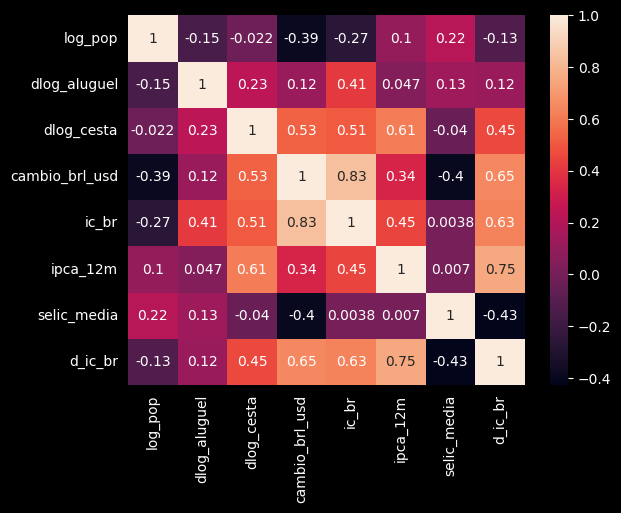

In [4]:
sns.heatmap(df_final[[
    "log_pop",
    "dlog_aluguel",
    "dlog_cesta",
    "cambio_brl_usd",
    "ic_br",
    "ipca_12m",
    "selic_media",
    "d_ic_br"
]].corr(), annot=True)

Vou usar somente d_ic_br nao ic_br

## Analisando relacao entre ipca aluguel e cesta basica

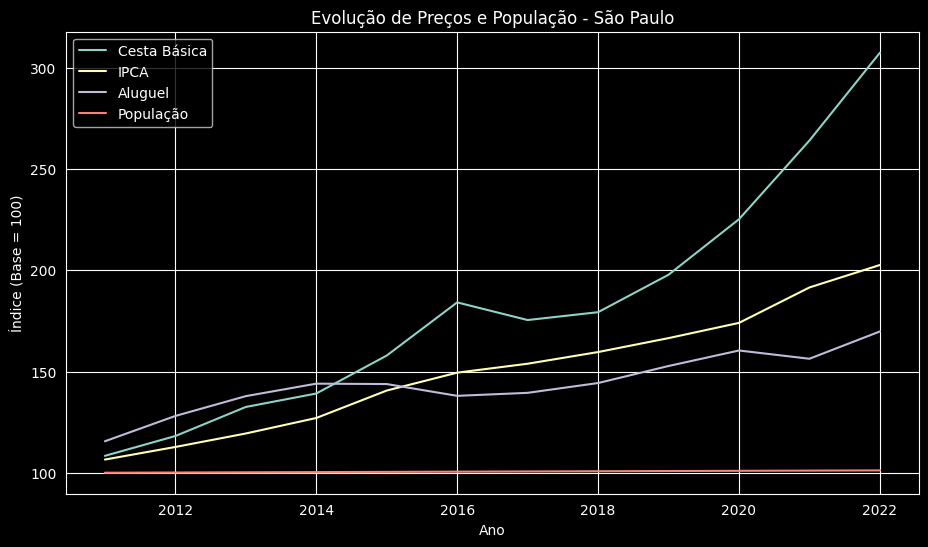

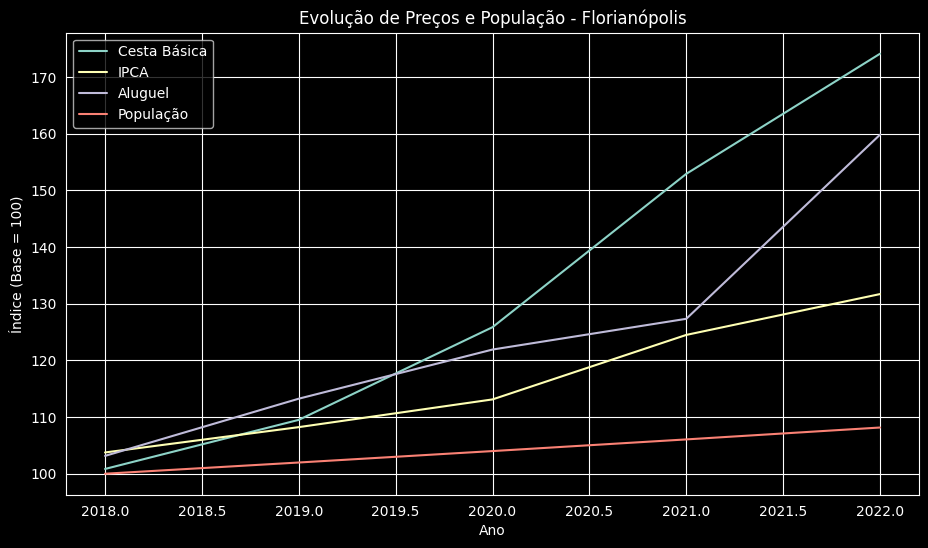

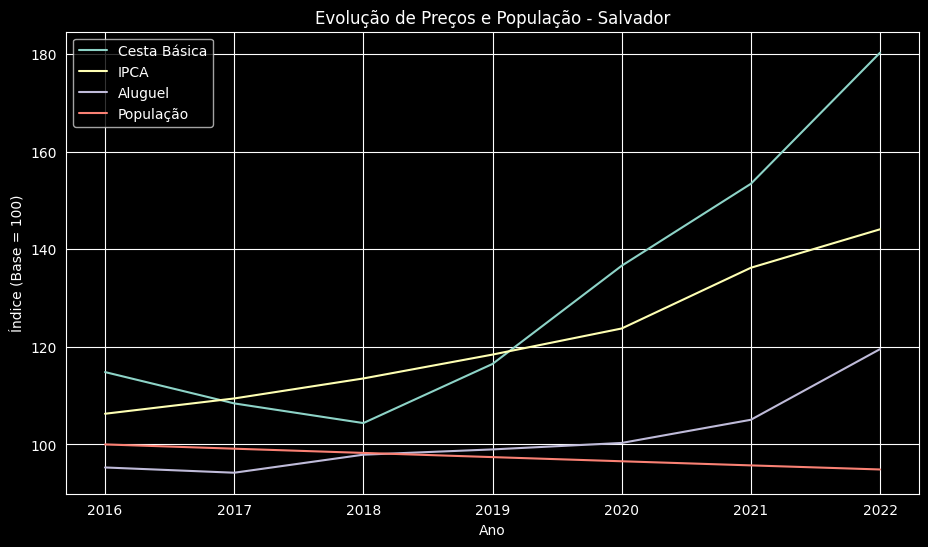

In [5]:
from src.pre_process.preprocess_aluguel_fipezap import plot_graph_prices

plot_graph_prices('São Paulo')
plot_graph_prices('Florianópolis')
plot_graph_prices('Salvador')

### Análise exploratória: evolução de preços e população nas capitais

Os gráficos apresentados mostram a evolução indexada (base = 100) da cesta básica, do índice de preços ao consumidor (IPCA), do preço do aluguel e da população para algumas capitais brasileiras ao longo do período analisado.

De forma geral, observa-se um padrão comum entre as cidades analisadas: a cesta básica apresenta crescimento significativamente superior ao IPCA ao longo do tempo. Esse comportamento indica que a inflação de alimentos nas cidades pode ser mais intensa do que a inflação média nacional, refletindo a maior volatilidade dos preços de produtos alimentícios, frequentemente influenciados por fatores como choques de oferta, variações cambiais e preços internacionais de commodities.

No caso de São Paulo, nota-se uma forte aceleração no índice da cesta básica a partir de meados da década de 2010, especialmente após 2020. Embora o preço do aluguel também apresente crescimento ao longo do período, sua trajetória é menos acentuada que a da cesta básica. O IPCA, por sua vez, apresenta crescimento mais suave e contínuo. A população da cidade permanece relativamente estável ao longo do tempo, sugerindo que o aumento dos preços, em particular da cesta básica, pode estar mais relacionado a fatores macroeconômicos do que a mudanças demográficas significativas.

Em Florianópolis, observa-se um comportamento semelhante para os preços, porém acompanhado de um crescimento mais perceptível da população. O aluguel apresenta trajetória ascendente relativamente próxima da evolução da cesta básica após 2020, o que pode indicar maior pressão sobre o mercado imobiliário local. Esse padrão pode refletir características típicas de cidades com forte dinamismo urbano e fluxo migratório, onde o crescimento populacional tende a pressionar a demanda por moradia.

Já em Salvador, observa-se um crescimento expressivo do índice da cesta básica ao longo do período mais recente, enquanto o aluguel apresenta aumento mais moderado. A população mostra pouca variação ao longo do tempo, sugerindo que a dinâmica de preços de alimentos pode não estar diretamente associada à pressão demográfica local. Esse resultado evidencia possíveis diferenças regionais na forma como o custo de vida e o mercado de habitação evoluem nas cidades brasileiras.

Em conjunto, esses resultados descritivos sugerem que o custo da cesta básica apresenta dinâmica distinta da inflação nacional medida pelo IPCA e pode exercer influência relevante sobre o custo de vida urbano. Além disso, a evolução do aluguel parece refletir tanto fatores macroeconômicos quanto características específicas de cada cidade, como crescimento populacional e dinâmica do mercado imobiliário. Esses padrões fornecem motivação empírica para a inclusão de variáveis como inflação da cesta básica e população na modelagem econométrica dos determinantes do preço do aluguel nas cidades brasileiras.


## Testando VIF para verificar a multicolineariedade


In [6]:

X = df_final[[
    "log_pop",
    "selic_media",
    "d_ic_br",
]]

import pandas as pd

vif = pd.DataFrame()
vif["variavel"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

      variavel        VIF
0      log_pop  10.392280
1  selic_media   7.137403
2      d_ic_br   2.428383


#### Por que log_pop tem VIF alto?

meus y serão:

dlog_cesta e dlog_aluguel

Isso é esperado porque:

cidades maiores
→ mercados mais dinâmicos
→ mais sensíveis a juros

Então log_pop se correlaciona com variáveis macro.

Mas:

log_pop é variável estrutural do modelo

Logo não deve ser removida.


## Seleção de variavris utilizando forward stepwise, critério de informação de Akaike (AIC)

Após o diagnóstico de multicolinearidade por meio do Variance Inflation Factor (VIF), foi aplicado um procedimento de seleção de variáveis do tipo forward stepwise utilizando o critério de informação de Akaike (AIC). Esse método adiciona iterativamente variáveis ao modelo de regressão, selecionando aquelas que reduzem o valor do AIC e, portanto, melhoram o ajuste do modelo penalizando a complexidade.

In [7]:
from src.pre_process.final_data_set import forward_selection

df = pd.read_csv("../data/processed/dataset_painel.csv")

predictors = [
"log_pop",
"selic_media",
"d_ic_br",
"dlog_cesta"
]

selected_vars = forward_selection(df, "dlog_aluguel", predictors)

print("Variáveis selecionadas:", selected_vars)

Variáveis selecionadas: ['dlog_cesta']


In [8]:
predictors = [
"log_pop",
"selic_media",
"d_ic_br",
"dlog_aluguel"
]

selected_vars = forward_selection(df, "dlog_cesta", predictors)

print("Variáveis selecionadas:", selected_vars)

Variáveis selecionadas: ['d_ic_br', 'dlog_aluguel']


### Seleção de Variáveis – Stepwise (AIC)

Quais variáveis apresentam maior contribuição para o ajuste dos modelos?

No primeiro exercício, considerando **`dlog_aluguel`** como variável dependente, o algoritmo selecionou apenas **`dlog_cesta`**. Esse resultado indica que a variação no custo da cesta básica possui o maior poder explicativo para a variação do aluguel entre as variáveis consideradas. As demais variáveis não foram incluídas pois sua adição não reduziu o AIC de forma suficiente para compensar o aumento da complexidade do modelo.

No segundo exercício, considerando **`dlog_cesta`** como variável dependente, as variáveis selecionadas foram **`d_ic_br`** e **`dlog_aluguel`**. Isso sugere que a variação do índice de preços considerado e a variação do aluguel apresentam maior capacidade de explicar as mudanças no custo da cesta básica no conjunto de dados analisado.

De forma geral, os resultados indicam uma relação consistente entre **variações no custo da cesta básica e no preço dos aluguéis**, sugerindo que ambos os preços respondem a pressões comuns do custo de vida urbano. Esses resultados servem como etapa exploratória para a especificação do modelo econométrico final.

### Modelo econométrico base (OLS)

O Stepwise serviu para exploração e seleção inicial de variáveis.
Agora você precisa estimar o modelo explicitamente.

In [17]:
X1 = df[[
    "log_pop",
    "dlog_cesta",
    "selic_media",
    "d_ic_br"
]]

X1 = sm.add_constant(X1)

y1 = df["dlog_aluguel"]

model_aluguel = sm.OLS(y1, X1).fit(cov_type="HC3")

print("\n==============================")
print("MODELO 1 - DETERMINANTES DO ALUGUEL")
print("==============================\n")

print(model_aluguel.summary())


MODELO 1 - DETERMINANTES DO ALUGUEL

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     1.987
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.105
Time:                        19:42:34   Log-Likelihood:                 108.84
No. Observations:                  79   AIC:                            -207.7
Df Residuals:                      74   BIC:                            -195.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       

In [16]:

X2 = df[[
    "log_pop",
    "d_ic_br",
    "dlog_aluguel"
]]

X2 = sm.add_constant(X2)

y2 = df["dlog_cesta"]

model_cesta = sm.OLS(y2, X2).fit(cov_type="HC3")

print("\n==============================")
print("MODELO 2 - DETERMINANTES DA CESTA BÁSICA")
print("==============================\n")

print(model_cesta.summary())


MODELO 2 - DETERMINANTES DA CESTA BÁSICA

                            OLS Regression Results                            
Dep. Variable:             dlog_cesta   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     8.085
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           9.79e-05
Time:                        19:42:09   Log-Likelihood:                 103.23
No. Observations:                  79   AIC:                            -198.5
Df Residuals:                      75   BIC:                            -189.0
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const

In [18]:
X3 = df[["dlog_cesta"]]

X3 = sm.add_constant(X3)

y3 = df["dlog_aluguel"]

model_stepwise = sm.OLS(y3, X3).fit(cov_type="HC3")

print("\n==============================")
print("MODELO 3 - MODELO SELECIONADO (STEPWISE)")
print("==============================\n")

print(model_stepwise.summary())


MODELO 3 - MODELO SELECIONADO (STEPWISE)

                            OLS Regression Results                            
Dep. Variable:           dlog_aluguel   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     6.283
Date:                Mon, 09 Mar 2026   Prob (F-statistic):             0.0143
Time:                        19:43:15   Log-Likelihood:                 106.21
No. Observations:                  79   AIC:                            -208.4
Df Residuals:                      77   BIC:                            -203.7
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    


---

# 1️⃣ Modelo 1 — Determinantes do aluguel

Modelo estimado:

$$
dlog\_aluguel =
\beta_0 +
\beta_1 log\_pop +
\beta_2 dlog\_cesta +
\beta_3 selic +
\beta_4 d\_ic\_br
$$

## Qualidade geral do modelo

| métrica     | valor |
| ----------- | ----- |
| R²          | 0.115 |
| R² ajustado | 0.067 |
| Prob(F)     | 0.105 |

Interpretação:

* o modelo explica cerca de **11,5% da variação do aluguel**
* o **F-test não é significativo a 5%**

Ou seja:

> o conjunto das variáveis não apresenta forte poder explicativo para a variação dos aluguéis.

Isso **não é incomum**, porque o mercado imobiliário depende de muitos fatores locais.

---

## Interpretação das variáveis

### População

```text
coef = -0.014
p = 0.150
```

Interpretação:

* efeito **negativo**
* **não significativo**

Isso significa que:

> não foi encontrada evidência estatística de que cidades mais populosas apresentam maior crescimento do preço dos aluguéis no período analisado.

Possível explicação:

* a população varia **muito lentamente**
* preços imobiliários respondem mais a **choques locais de mercado**

---

### Cesta básica

```text
coef = 0.161
p = 0.101
```

Interpretação:

* efeito **positivo**
* significância **fraca (10%)**

Isso sugere que:

> aumentos no custo da cesta básica podem estar associados a aumentos no preço dos aluguéis.

Esse resultado é consistente com a ideia de **pressão geral do custo de vida urbano**.

---

### Selic

```text
coef = 0.004
p = 0.126
```

Interpretação:

* efeito pequeno
* **não significativo**

Possível interpretação econômica:

* a taxa Selic afeta crédito imobiliário
* mas seu efeito sobre aluguéis no curto prazo é limitado.

---

### Índice de commodities

```text
coef = 0.044
p = 0.342
```

Sem evidência estatística de efeito sobre aluguéis.

---

# 2️⃣ Modelo 2 — Determinantes da cesta básica

Modelo:

$$
dlog_cesta =
\beta_0 +
\beta_1 log\_pop +
\beta_2 d\_ic\_br +
\beta_3 dlog\_aluguel
$$

---

## Qualidade do modelo

| métrica     | valor        |
| ----------- | ------------ |
| R²          | 0.242        |
| R² ajustado | 0.212        |
| Prob(F)     | **0.000097** |

Interpretação:

> o modelo explica cerca de **24% da variação da cesta básica**, sendo estatisticamente significativo.

Esse ajuste é **consideravelmente melhor que o modelo do aluguel**.

---

## Interpretação das variáveis

### População

```text
coef = 0.0056
p = 0.479
```

Sem significância estatística.

Ou seja:

> não há evidência de que cidades mais populosas apresentem maior inflação da cesta básica.

Isso faz sentido porque:

* preços de alimentos são **mais determinados por fatores nacionais**

---

### Índice de commodities

```text
coef = 0.2058
p = 0.000
```

Esse é o **resultado mais forte do modelo**.

Interpretação:

> um aumento de 1% no índice considerado está associado a um aumento de aproximadamente **0,21% no custo da cesta básica**.

Isso confirma que **choques de preços de commodities afetam diretamente alimentos**.

---

### Aluguel

```text
coef = 0.218
p = 0.048
```

Interpretação:

* efeito **positivo**
* **significativo a 5%**

Isso sugere que:

> aumentos no preço dos aluguéis estão associados a aumentos no custo da cesta básica.

Uma possível interpretação é que **cidades com pressões de custo urbano maiores apresentam inflação local mais elevada**.

---

# 3️⃣ Modelo 3 — Modelo parsimonioso (Stepwise)

Modelo:

$$
dlog_aluguel = \beta_0 + \beta_1 dlog\_cesta
$$

---

## Qualidade do modelo

| métrica | valor     |
| ------- | --------- |
| R²      | 0.054     |
| Prob(F) | **0.014** |

Apesar do R² baixo:

* o modelo é **estatisticamente significativo**

---

## Interpretação do coeficiente

```text
coef = 0.1999
p = 0.012
```

Interpretação:

> um aumento de **1% no custo da cesta básica** está associado a um aumento de aproximadamente **0,20% no preço dos aluguéis**.

Esse resultado sugere uma **relação positiva entre custo de alimentação e preços de moradia**, refletindo pressões gerais do custo de vida nas cidades.

---

# 4️⃣ Diagnóstico dos modelos

### Normalidade dos resíduos

Jarque-Bera:

* Modelo 1 → OK
* Modelo 2 → OK

Ou seja:

```text
resíduos aproximadamente normais
```

---

### Autocorrelação

Durbin-Watson:

| modelo   | valor |
| -------- | ----- |
| modelo 1 | 1.55  |
| modelo 2 | 2.14  |
| modelo 3 | 1.56  |

Interpretação:

* modelo 2 → ideal
* modelos 1 e 3 → leve autocorrelação positiva

Nada crítico.

---

# 5️⃣ O que os resultados sugerem

Os resultados indicam que:

1️⃣ **choques de preços de commodities influenciam diretamente a cesta básica**

2️⃣ **variações no custo da cesta básica estão associadas a aumentos no preço dos aluguéis**

3️⃣ **variáveis macroeconômicas e demográficas apresentam menor poder explicativo para o comportamento do aluguel no período analisado**

---

# 6️⃣ Insight econômico importante

Seu resultado sugere um **mecanismo de transmissão de preços**:

```text
commodities
     ↓
cesta básica
     ↓
aluguel
```

Ou seja:

> pressões inflacionárias no custo de alimentos podem estar associadas a aumentos no custo geral de vida urbano.

---

# 7️⃣ Próximo passo econométrico

Agora você precisa rodar:

### Modelo de painel (Fixed Effects)

Porque seus dados são:

```text
cidade × ano
```

Isso controla:

* características fixas das cidades
* heterogeneidade estrutural.

---

✅ **Resumo para o TCC**

Seu resultado principal até agora:

> variações no custo da cesta básica apresentam associação positiva com o preço dos aluguéis, enquanto choques no índice de preços considerado explicam parte relevante da inflação de alimentos nas cidades analisadas.

---

Se quiser, eu também posso te mostrar **um problema econométrico que aparece no seu modelo (simultaneidade entre aluguel e cesta)** e como resolver — isso deixaria seu TCC **muito mais sofisticado**.


---
---

### Fixed Effects

O modelo de **efeitos fixos** controla características **não observadas das cidades** que não mudam ao longo do tempo, como por exemplo:

* infraestrutura urbana
* renda média
* localização geográfica
* estrutura econômica

A ideia é estimar:

$$
Y_{it} = \alpha_i + \beta X_{it} + \epsilon_{it}
$$

onde:

* (i) = cidade
* (t) = tempo
* (\alpha_i) = efeito fixo da cidade

Isso significa que o modelo analisa **apenas variações dentro da mesma cidade ao longo do tempo**.


In [21]:
df_panel = df.set_index(["cidade", "ano"])

# variáveis explicativas
X = df_panel[[
    "log_pop",
    "dlog_cesta",
    "selic_media",
    "d_ic_br"
]]

X = sm.add_constant(X)

y = df_panel["dlog_aluguel"]

# modelo de efeitos fixos
model_fe_aluguel = PanelOLS(
    y,
    X,
    entity_effects=True
)

results_aluguel = model_fe_aluguel.fit()

print(results_aluguel)

                          PanelOLS Estimation Summary                           
Dep. Variable:           dlog_aluguel   R-squared:                        0.1121
Estimator:                   PanelOLS   R-squared (Between):             -165.39
No. Observations:                  79   R-squared (Within):               0.1121
Date:                Mon, Mar 09 2026   R-squared (Overall):             -22.824
Time:                        20:02:09   Log-likelihood                    113.47
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2.0209
Entities:                          11   P-value                           0.1020
Avg Obs:                       7.1818   Distribution:                    F(4,64)
Min Obs:                       5.0000                                           
Max Obs:                       12.000   F-statistic (robust):             2.0209
                            

In [22]:
X = df_panel[[
    "log_pop",
    "d_ic_br",
    "dlog_aluguel"
]]

X = sm.add_constant(X)

y = df_panel["dlog_cesta"]

model_fe_cesta = PanelOLS(
    y,
    X,
    entity_effects=True
)

results_cesta = model_fe_cesta.fit()

print(results_cesta)

                          PanelOLS Estimation Summary                           
Dep. Variable:             dlog_cesta   R-squared:                        0.2479
Estimator:                   PanelOLS   R-squared (Between):             -125.56
No. Observations:                  79   R-squared (Within):               0.2479
Date:                Mon, Mar 09 2026   R-squared (Overall):             -2.4407
Time:                        20:02:45   Log-likelihood                    104.12
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      7.1417
Entities:                          11   P-value                           0.0003
Avg Obs:                       7.1818   Distribution:                    F(3,65)
Min Obs:                       5.0000                                           
Max Obs:                       12.000   F-statistic (robust):             7.1417
                            

# 📊 Modelo 1 — Determinantes da variação do aluguel

**Variável dependente:**

* `dlog_aluguel` → variação % do aluguel

**Equação estimada (aprox.):**

$$
\Delta \log(aluguel) =
-5.27 + 0.35\log(pop) + 0.16\Delta\log(cesta) + 0.0042,selic + 0.039\Delta IC
$$

## Principais resultados

| Variável    | Coeficiente | Significância       | Interpretação                                                                 |
| ----------- | ----------- | ------------------- | ----------------------------------------------------------------------------- |
| log_pop     | 0.354       | ❌ não significativo | cidades maiores tendem a ter aluguel maior, mas efeito estatisticamente fraco |
| dlog_cesta  | 0.161       | ❌ p=0.15            | inflação da cesta tende a elevar aluguel                                      |
| selic_media | 0.0042      | ⚠️ p=0.068          | juros maiores aumentam levemente aluguel                                      |
| d_ic_br     | 0.038       | ❌ não significativo | ciclo econômico fraco no aluguel                                              |

## Interpretação econômica

💡 **Selic tem efeito marginal positivo no aluguel**
Possíveis razões:

* juros altos → financiamento imobiliário mais caro
* mais gente permanece **alugando**
* pressão de demanda no aluguel

📈 **Cesta básica e aluguel caminham juntos**, sugerindo **pressão inflacionária geral**.

## Qualidade do modelo

* **R² within = 0.11** → explica **11% da variação dentro das cidades**
* **F-test p=0.102** → modelo **não significativo a 5%**, mas próximo de 10%

➡️ Modelo tem **poder explicativo baixo**, mas indica algumas relações plausíveis.

---

# 📊 Modelo 2 — Determinantes da variação da cesta básica

**Variável dependente:**

* `dlog_cesta` → inflação da cesta básica

**Equação estimada:**

$$
\Delta \log(cesta) =
-2.21 + 0.15\log(pop) + 0.208\Delta IC + 0.237\Delta\log(aluguel)
$$

## Principais resultados

| Variável     | Coeficiente | Significância       | Interpretação                              |
| ------------ | ----------- | ------------------- | ------------------------------------------ |
| log_pop      | 0.152       | ❌ não significativo | tamanho da cidade pouco relevante          |
| d_ic_br      | **0.208**   | ✅ **p=0.0001**      | atividade econômica aumenta preço da cesta |
| dlog_aluguel | 0.236       | ⚠️ p=0.079          | aluguel pressiona custo da cesta           |

## Interpretação econômica

📈 **Ciclo econômico afeta fortemente a cesta básica**

* aumento no **IC-Br** → maior demanda → preços sobem

💡 **Aluguel também impacta a cesta**

Possível mecanismo:

* custos imobiliários ↑
* custo operacional de comércio ↑
* repasse para preços

---

# 📊 Comparação entre os modelos

| Métrica                  | Modelo 1 | Modelo 2             |
| ------------------------ | -------- | -------------------- |
| R²                       | 0.11     | **0.25**             |
| Significância geral      | fraca    | **forte (p=0.0003)** |
| Variável mais importante | Selic    | **IC-Br**            |

➡️ **Modelo 2 é estatisticamente mais robusto.**

---

# 🔁 Relação interessante entre as equações

Existe uma **retroalimentação**:

* **Cesta ↑ → aluguel ↑** (modelo 1)
* **Aluguel ↑ → cesta ↑** (modelo 2)

Isso sugere **dinâmica de inflação urbana**.

Possível interpretação:

```
atividade econômica ↑
       ↓
cesta básica ↑
       ↓
pressão de custo urbano ↑
       ↓
aluguel ↑
       ↓
custo do comércio ↑
       ↓
cesta ↑
```

---

# ⚠️ Pontos econométricos a considerar

1️⃣ **Possível simultaneidade**

* aluguel influencia cesta
* cesta influencia aluguel

➡️ pode gerar **endogeneidade**

Métodos possíveis:

* **VAR em painel**
* **GMM Arellano-Bond**
* **instrumentos**

---

2️⃣ **Erros não robustos**

```
Cov estimator: Unadjusted
```

Ideal usar:

* **clustered por entidade**
* **Driscoll-Kraay**

---

3️⃣ **Pouca variação temporal**

* painel pequeno (79 observações)

---

# 📌 Conclusão econômica

Principais insights:

✔ **Ciclo econômico (IC-Br) é determinante para preços da cesta**
✔ **Inflação urbana parece interligar aluguel e cesta básica**
✔ **Selic pode pressionar aluguel via mercado imobiliário**